<a href="https://colab.research.google.com/github/Prajjwal-001-py/Car-Resale-Price-Prediction-Model/blob/main/Car_Resale_Price_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
#Importing basic Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
#Reading the dataset

data = pd.read_csv('data2.csv')
data.head()

,Age,Mileage,Horsepower,Price
0,1,5000,250,35000
1,1,8000,190,31500
2,2,12000,180,28000
3,2,15000,160,26500
4,2,22000,150,24000


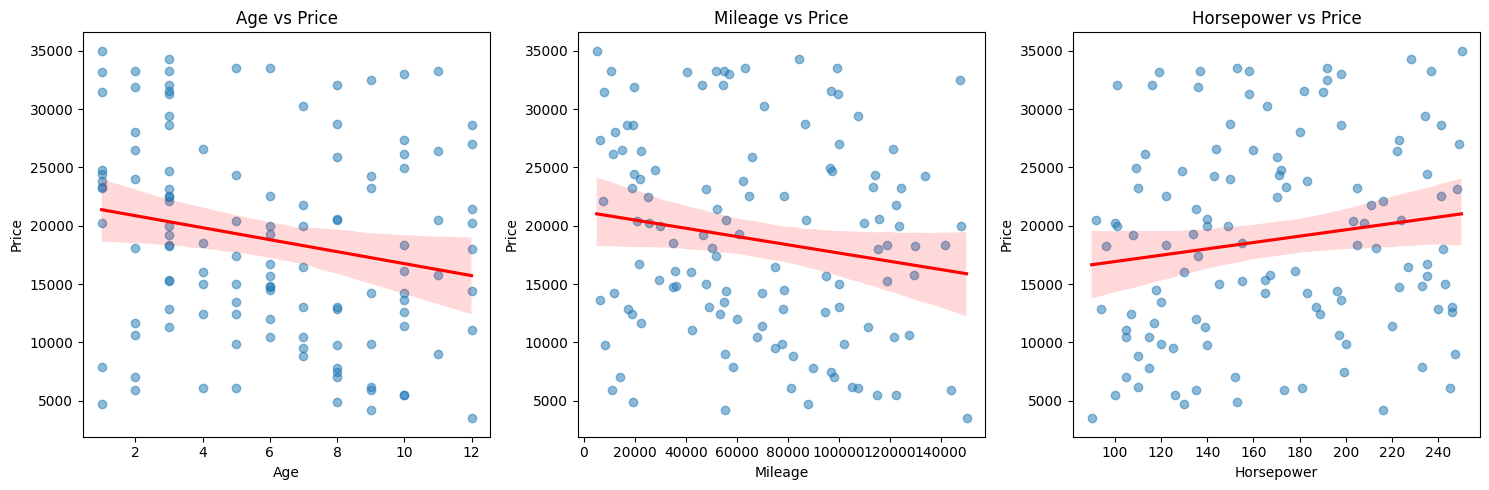

In [81]:
# Visualisation of the dataset

features = ['Age', 'Mileage', 'Horsepower']
plt.figure(figsize=(15, 5))

for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.regplot(x=data[col], y=data['Price'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f'{col} vs Price')

plt.tight_layout()
plt.show()

In [60]:
# Formation of input and output arrays

x = data[['Age','Mileage','Horsepower']].values
y = data[['Price']].values

In [61]:
# Z score normalisation for scaling of input data

mean = np.mean(x, axis = 0)
std = np.std(x, axis = 0)
x_scal =  (x - mean)/(std + 1e-8)

[[-1.47634657 -1.54876356  1.70713441]
 [-1.47634657 -1.4746325   0.44622266]
 [-1.18156855 -1.37579109  0.2360707 ]
 [-1.18156855 -1.30166003 -0.18423322]
 [-1.18156855 -1.12868756 -0.39438518]
 [-0.88679053 -1.05455651  0.02591874]
 [-0.88679053 -0.93100474 -0.60453714]
 [-0.59201252 -0.80745298 -0.2893092 ]
 [-0.59201252 -0.63448051 -0.81468909]
 [-0.2972345  -0.4862184  -0.49946116]
 [-0.2972345  -0.31324593 -1.02484105]
 [-0.00245648 -0.18969417 -0.70961312]
 [-0.00245648  0.00798865 -1.12991703]
 [ 0.29232153  0.18096112 -0.91976507]
 [ 0.29232153  0.35393359 -1.23499301]
 [ 0.58709955  0.55161641 -1.12991703]
 [ 0.58709955  0.74929923 -1.34006899]
 [ 0.88187757  0.92227169 -1.23499301]
 [ 1.17665558  1.16937522 -1.44514497]
 [ 1.76621162  2.03423756 -1.65529693]
 [-0.2972345  -1.16212067  0.71942021]
 [ 1.76621162 -1.03985385 -1.44514497]
 [-0.88679053  0.72246378  0.27810109]
 [-0.88679053 -0.53057348 -1.10890184]
 [ 0.58709955 -1.19278622 -0.33133959]
 [-0.2972345   0.84641091

In [62]:
# Addition of a bias column to get the intercept

x_b = np.ones((x_scal.shape[0], 1))

x_int = np.concatenate((x_b,x_scal), axis = 1)
print(x_int)

[[ 1.         -1.47634657 -1.54876356  1.70713441]
 [ 1.         -1.47634657 -1.4746325   0.44622266]
 [ 1.         -1.18156855 -1.37579109  0.2360707 ]
 [ 1.         -1.18156855 -1.30166003 -0.18423322]
 [ 1.         -1.18156855 -1.12868756 -0.39438518]
 [ 1.         -0.88679053 -1.05455651  0.02591874]
 [ 1.         -0.88679053 -0.93100474 -0.60453714]
 [ 1.         -0.59201252 -0.80745298 -0.2893092 ]
 [ 1.         -0.59201252 -0.63448051 -0.81468909]
 [ 1.         -0.2972345  -0.4862184  -0.49946116]
 [ 1.         -0.2972345  -0.31324593 -1.02484105]
 [ 1.         -0.00245648 -0.18969417 -0.70961312]
 [ 1.         -0.00245648  0.00798865 -1.12991703]
 [ 1.          0.29232153  0.18096112 -0.91976507]
 [ 1.          0.29232153  0.35393359 -1.23499301]
 [ 1.          0.58709955  0.55161641 -1.12991703]
 [ 1.          0.58709955  0.74929923 -1.34006899]
 [ 1.          0.88187757  0.92227169 -1.23499301]
 [ 1.          1.17665558  1.16937522 -1.44514497]
 [ 1.          1.76621162  2.03

In [63]:
# Applying closed form of Linear regression

B =np.linalg.inv(x_int.T.dot(x_int)).dot(x_int.T).dot(y)
print(B)

[[18806.625     ]
 [-1481.82427216]
 [-1067.97892826]
 [ 1066.32888531]]


In [77]:
# Formation of function for Prediction of Resale Price

def predict(age,Mileage,HP):
  N = np.array([1, (age - mean[0])/(std[0]+1e-8), (Mileage-mean[1])/(std[1]+1e-8),(HP-mean[2])/(std[2]+1e-8)])
  value = N.dot(B)[0]
  price = max(0,value)
  if HP<=0:
    print("Car's engine is not working. Resale Price is: $100")
  else:
    print(f"Resale Price of the Car is: ${price:,.2f}")

In [78]:
predict(10,00,00)

Car's engine is not working. Resale Price is: $100
